Importing Libraries

These lines load all the tools needed for image processing, ML, XGBoost, and training.

In [ ]:
import os
import cv2
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from xgboost import XGBClassifier
from google.colab import drive

Mount Google Drive

This allows accessing your dataset inside Drive.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Define Dataset Path

Tell the script where images are stored.

In [ ]:
dataset_path = '/content/drive/My Drive/images'

In [ ]:
# Load MobileNetV2
# ============================

# It only extracts 1280-D deep features from each image.
base_model = MobileNetV2(
    weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3)
)

# Freezes the model (no training needed):
for layer in base_model.layers:
    layer.trainable = False


# Augmentation Functions - These functions randomly modify images(Random brightness,Noise)
# ============================
def random_brightness(img):
    factor = random.uniform(0.6, 1.4) #for brightness
    return np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8) # converted from int to float prevents overflow issues

def random_noise(img):
    noise = np.random.normal(0, 10, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def cutout(img):
    h, w, _ = img.shape
    size = random.randint(20, 50)
    x = random.randint(0, w - size)
    y = random.randint(0, h - size)
    img[y:y+size, x:x+size] = 0
    return img

def random_blur(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

def random_sharpen(img):
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    return cv2.filter2D(img, -1, kernel)

def random_flip(img):
    return cv2.flip(img, 1)

def augment_image(img):
    funcs = [random_brightness, random_noise, cutout, random_blur, random_sharpen, random_flip]
    for f in random.sample(funcs, 2):
        img = f(img)
    return img


# Load Dataset
# ============================
X, y = [], [] #features n label(folder name)
valid_exts = ('.jpg', '.jpeg', '.png')

# Reads each traffic class folder.
for label in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, label)
    if not os.path.isdir(folder):
        continue

    for img_name in os.listdir(folder):
        if not img_name.lower().endswith(valid_exts):
            continue

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Reads image, converts to RGB, resizes to 224×224.
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))

        # Pass image into MobileNetV2 → return a 1280-length feature
        inp = preprocess_input(np.expand_dims(img, 0))
        feat = base_model.predict(inp, verbose=0).flatten()

        # Store the extracted features and its class label.
        X.append(feat)
        y.append(label)

        # 6 extra augmented samples per image.
        for _ in range(6):
            aug = augment_image(img.copy())
            aug_inp = preprocess_input(np.expand_dims(aug, 0))
            feat_aug = base_model.predict(aug_inp, verbose=0).flatten()

            X.append(feat_aug)
            y.append(label)

X = np.array(X)
y = np.array(y)


# Encode & Scale - Converts labels into integer labels (0,1,2...).
# ============================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardizes the feature vectors.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Train/Test Data - Uses 80% for training, 20% for testing.
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Train XGBoost Model - on extracted features n Predicts class as low / moderate / high.
# ============================
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=700,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    gamma=0.15,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    tree_method='hist'
)

xgb.fit(X_train, y_train)

# Evaluate the Model - Prints accuracy + per-class performance.
# ===========================
y_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 90.12605042016807
                                           precision    recall  f1-score   support

1 high traffic(heavy vehicles congestion)       0.95      0.97      0.96       154
        2 moderate traffic(not congested)       0.85      0.87      0.86       154
              3 low traffic(few vehicles)       0.94      0.94      0.94       153
                                 test_img       0.25      0.13      0.17        15

                                 accuracy                           0.90       476
                                macro avg       0.75      0.73      0.73       476
                             weighted avg       0.89      0.90      0.90       476



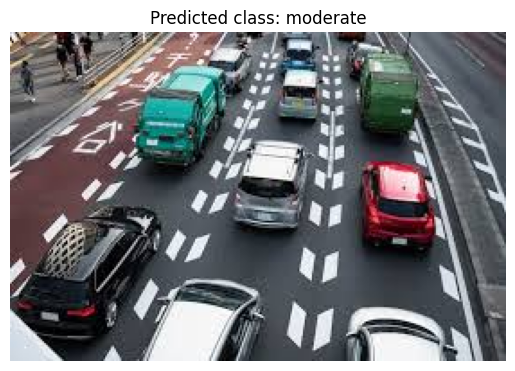

Predicted class: moderate


In [ ]:
# Predict an Image (Testing Only)
def normalize_label_for_testing(lbl):
    s = str(lbl).lower()

    if "low" in s or "few" in s:
        return "low"
    if "mod" in s or "medium" in s or "not congested" in s:
        return "moderate"
    if "high" in s or "heavy" in s or "congest" in s:
        return "high"

    # fallback for unknown/extra folder names like 'test_img'
    return "moderate"

def predict_image(img_path, base_model, scaler, xgb_model, label_encoder):
    import cv2
    import numpy as np
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    import matplotlib.pyplot as plt

    # Load and preprocess image
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found or unreadable.")

    # Convert BGR (OpenCV default) to RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for model input
    img_resized = cv2.resize(img_rgb, (224, 224))
    x = image.img_to_array(img_resized)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Extract deep features
    features = base_model.predict(x, verbose=0).flatten().reshape(1, -1)

    # Scale features
    features_scaled = scaler.transform(features)

    pred = xgb_model.predict(features_scaled)
    raw_label = label_encoder.inverse_transform(pred)[0]

    # convert label to low / moderate / high
    class_name = normalize_label_for_testing(raw_label)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Predicted class: {class_name}")
    plt.show()

    return class_name

# Example usage
test_img_path = '/content/drive/My Drive/images/test_img/m.jpg'
predicted_class = predict_image(test_img_path, base_model, scaler, xgb, le)
print("Predicted class:", predicted_class)

Save Model Files

In [ ]:
import pickle
# Saves 3 files needed for Streamlit app.
# Save the model
with open("/content/drive/MyDrive/traffic_xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save the label encoder
with open("/content/drive/MyDrive/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Save the scaler
with open("/content/drive/MyDrive/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [ ]:
import os
import random
import pickle
import heapq
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2

Load Saved Models for Routing System

In [ ]:
xgb = pickle.load(open("/content/drive/My Drive/traffic_xgb_model.pkl", "rb"))
le = pickle.load(open("/content/drive/My Drive/label_encoder.pkl", "rb"))
scaler = pickle.load(open("/content/drive/My Drive/scaler.pkl", "rb"))
base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")

/tmp/ipykernel_1789/2639518079.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


In [ ]:
DATASET_ROOT = "/content/drive/My Drive/images"

traffic_cost = {
    "low": 1,
    "moderate": 5,
    "high": 10
}

Road Graph (Traffic Nodes)

In [ ]:
# ROAD GRAPH
# ------------------------------------------------------
graph = {
    "Bengaluru": ["MG Road", "Richmond Town", "Domlur"],

    "MG Road": ["Bengaluru", "Brigade Road", "Ulsoor"],

    "Richmond Town": ["Bengaluru", "Langford Road", "Adugodi"],

    "Domlur": ["Bengaluru", "Indiranagar", "Ejipura"],

    "Brigade Road": ["MG Road", "Richmond Town", "Adugodi"],

    "Ulsoor": ["MG Road", "Indiranagar", "CMH Road"],

    "Langford Road": ["Richmond Town", "Adugodi", "Shantinagar"],

    "Adugodi": ["Richmond Town", "Brigade Road", "Koramangala"],

    "Indiranagar": ["Domlur", "Ulsoor", "CMH Road"],

    "Ejipura": ["Domlur", "Koramangala", "Madiwala"],

    "CMH Road": ["Ulsoor", "Indiranagar", "100 Feet Road"],

    "100 Feet Road": ["CMH Road"],

    "Madiwala": ["Ejipura", "Koramangala", "Silk Board"],

    "Shantinagar": ["Langford Road", "Richmond Town", "Adugodi"],

    "Koramangala": ["Adugodi", "Ejipura", "Madiwala"]
}



IMAGE PREVIEW FOR ROUTE NODES:

Domlur — MODERATE


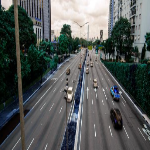


Ejipura — LOW


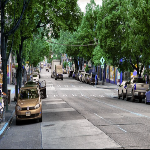


BEST ROUTE: Bengaluru → Domlur → Ejipura → Koramangala


In [ ]:
# Converts whatever label XGBoost predicts (sometimes long strings) into clean class names: low, moderate, high.
def normalize_label(lbl):
    lbl = lbl.lower()
    if "low" in lbl: return "low"
    if "moderate" in lbl: return "moderate"
    if "high" in lbl: return "high"
    return "moderate"

# Random Image Assignment -
  # Selects a random folder (low/moderate/high) from dataset.
  # Selects a random image inside that folder.
  # Helps simulate real-time traffic camera input for each node.
def get_random_image(root):
    folders = [os.path.join(root, d) for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    folder = random.choice(folders)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))]
    return os.path.join(folder, random.choice(imgs))

# It preprocesses the image, extracts 1280-D MobileNetV2 features, scales them, predicts traffic using XGBoost, and returns a clean label (low/moderate/high).
def classify_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, 0)
    x = preprocess_input(x)

    feat = base_model.predict(x, verbose=0).flatten()
    feat_scaled = scaler.transform([feat])

    pred = xgb.predict(feat_scaled)[0]
    label = le.inverse_transform([pred])[0]
    return normalize_label(label)

# For every node in the road network graph, assigns a random traffic image.
def assign_node_images(graph, source, dest):
    imgs = {}
    for node in graph:
        if node not in [source, dest]:
            imgs[node] = get_random_image(DATASET_ROOT)
    return imgs

# For each node:
  # If node = source/destination → assign low traffic
  # Otherwise → classify image using ML model
def classify_nodes(graph, imgs, source, dest):
    node_tr = {}
    for node in graph:
        if node in [source, dest]:
            node_tr[node] = "low"
        else:
            node_tr[node] = classify_image(imgs[node])
    return node_tr

# Computes shortest path where weight = traffic congestion.
# low traffic gets small weight → preferred.
def dijkstra(source, dest, graph, node_tr):
    pq = [(0, source, [source])]
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)

        if node == dest:
            return path

        for nei in graph[node]:
            w = traffic_cost[node_tr[nei]]
            heapq.heappush(pq, (cost + w, nei, path + [nei]))

    return None

source = "Bengaluru"
destination = "Koramangala"

# assign_node_images → each node gets a random traffic image
node_images = assign_node_images(graph, source, destination)

# classify_nodes → ML model predicts traffic for every node
node_traffic = classify_nodes(graph, node_images, source, destination)

# dijkstra → computes the best (least congested) route
best_path = dijkstra(source, destination, graph, node_traffic)

print("\nIMAGE PREVIEW FOR ROUTE NODES:")
for node in best_path:
    if node not in [source, destination]:

        print(f"\n{node} — {node_traffic[node].upper()}")

        img_path = node_images[node]
        img = cv2.imread(img_path)

        if img is None:
            print("⚠ Could not load:", img_path)
            continue

        # Convert BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize (make small)
        img = cv2.resize(img, (150, 150))

        from google.colab.patches import cv2_imshow
        cv2_imshow(img)

# AFTER showing images, show the route
print("\nBEST ROUTE:", " → ".join(best_path))

In [ ]:
# app.py (Updated Clean Version)
%%writefile app.py
import os
import random
import pickle
import heapq
import cv2
import numpy as np
import streamlit as st

from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2

# ----------------------------
# Paths (change if needed)
# ----------------------------
XGB_PATH = "/content/drive/My Drive/traffic_xgb_model.pkl"
LE_PATH  = "/content/drive/My Drive/label_encoder.pkl"
SCALER_PATH = "/content/drive/My Drive/scaler.pkl"
DATASET_ROOT = "/content/drive/My Drive/images"

# ----------------------------
# Load models / artifacts
# ----------------------------
@st.cache_resource(show_spinner=False)
def load_artifacts():
    # load ML artifacts (will cache across reruns)
    with open(XGB_PATH, "rb") as f:
        xgb = pickle.load(f)
    with open(LE_PATH, "rb") as f:
        le = pickle.load(f)
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)

    # feature extractor (MobileNetV2 to match training notebook)
    base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
    return xgb, le, scaler, base_model

try:
    xgb, le, scaler, base_model = load_artifacts()
except FileNotFoundError as e:
    st.error("Could not load one or more model files. Check file paths.")
    st.stop()

# ----------------------------
# Traffic cost mapping
# ----------------------------
traffic_cost = {
    "low": 1,
    "moderate": 5,
    "high": 10
}

# ----------------------------
# Road graph (same as your code)
# ----------------------------
graph = {
    "Bengaluru": ["MG Road", "Richmond Town", "Domlur"],
    "MG Road": ["Bengaluru", "Brigade Road", "Ulsoor"],
    "Richmond Town": ["Bengaluru", "Langford Road", "Adugodi"],
    "Domlur": ["Bengaluru", "Indiranagar", "Ejipura"],
    "Brigade Road": ["MG Road", "Richmond Town", "Adugodi"],
    "Ulsoor": ["MG Road", "Indiranagar", "CMH Road"],
    "Langford Road": ["Richmond Town", "Adugodi", "Shantinagar"],
    "Adugodi": ["Richmond Town", "Brigade Road", "Koramangala"],
    "Indiranagar": ["Domlur", "Ulsoor", "CMH Road"],
    "Ejipura": ["Domlur", "Koramangala", "Madiwala"],
    "CMH Road": ["Ulsoor", "Indiranagar", "100 Feet Road"],
    "100 Feet Road": ["CMH Road"],
    "Madiwala": ["Ejipura", "Koramangala", "Silk Board"],
    "Shantinagar": ["Langford Road", "Richmond Town", "Adugodi"],
    "Koramangala": ["Adugodi", "Ejipura", "Madiwala"]
}

# ----------------------------
# Helper functions (same logic)
# ----------------------------
def normalize_label(lbl):
    lbl = str(lbl).lower()
    if "low" in lbl:
        return "low"
    if "moderate" in lbl:
        return "moderate"
    if "high" in lbl:
        return "high"
    return "moderate"

def get_random_image(root):
    # choose a random image from a random class folder under root
    folders = [os.path.join(root, d) for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d))]
    if not folders:
        raise FileNotFoundError("No subfolders found under DATASET_ROOT")
    folder = random.choice(folders)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not imgs:
        raise FileNotFoundError(f"No images found in folder: {folder}")
    return os.path.join(folder, random.choice(imgs))

def classify_image(path):
    # returns normalized label: "low" / "moderate" / "high"
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Unable to read image: {path}")
    img = cv2.resize(img, (224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, 0)
    x = preprocess_input(x)

    feat = base_model.predict(x, verbose=0).flatten()  # expect 1280 dim for MobileNetV2
    feat_scaled = scaler.transform([feat])
    pred = xgb.predict(feat_scaled)[0]
    label = le.inverse_transform([pred])[0]
    return normalize_label(label)

def assign_node_images(graph, source, dest):
    imgs = {}
    for node in graph:
        if node not in [source, dest]:
            imgs[node] = get_random_image(DATASET_ROOT)
    return imgs

def classify_nodes(graph, imgs, source, dest):
    node_tr = {}
    for node in graph:
        if node in [source, dest]:
            node_tr[node] = "low"
        else:
            node_tr[node] = classify_image(imgs[node])
    return node_tr

def dijkstra(source, dest, graph, node_tr):
    # returns path list or None
    pq = [(0, source, [source])]
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)

        if node == dest:
            return path

        for nei in graph.get(node, []):
            w = traffic_cost.get(node_tr.get(nei, "moderate"), 5)
            heapq.heappush(pq, (cost + w, nei, path + [nei]))

    return None

# ----------------------------------------------
# CUSTOM CSS (STYLING + CENTERED TITLE)
# ----------------------------------------------
st.markdown("""
<style>

    /* Animated Gradient Background */
    .stApp {
        background: linear-gradient(135deg, #0f0f0f, #1c1c1c, #111827);
        background-size: 400% 400%;
        animation: gradientMove 14s ease infinite;
    }

    @keyframes gradientMove {
        0% {background-position: 0% 50%;}
        50% {background-position: 100% 50%;}
        100% {background-position: 0% 50%;}
    }

    /* Center Title + Keep in One Line */
    h1 {
        text-align: center !important;
        white-space: nowrap !important;
        font-size: 38px !important;
        color: #f8f8f8 !important;
        text-shadow: 0px 0px 15px rgba(0, 255, 200, 0.4);
    }

    /* Text Color */
    label, .css-16idsys {
        color: #f5f5f5 !important;
    }

    /* Dropdown Styling */
    .stSelectbox > div > div {
        background-color: #1f2937 !important;
        color: white !important;
    }

    /* Button Styling */
    .stButton button {
        background-color: #22c55e !important;
        color: white !important;
        padding: 8px 20px;
        border-radius: 8px;
        border: none;
    }
    .stButton button:hover {
        background-color: #16a34a !important;
    }

</style>
""", unsafe_allow_html=True)


# ----------------------------
# Streamlit UI
# ----------------------------
st.set_page_config(page_title="Smart Traffic Route Finder", layout="centered")
st.title("🚦 Smart Traffic-Based Route Finder")

# Shows two dropdown menus.
nodes = list(graph.keys())
col1, col2 = st.columns(2)
with col1:
    source = st.selectbox("Select Source", nodes, index=0)
with col2:
    destination = st.selectbox("Select Destination", nodes, index=len(nodes)-1)

# When clicked, it begins the full traffic analysis + routing process.
if st.button("Find Best Route"):
    if source == destination:
        st.error("Source and destination cannot be the same.")
    else:
        try:
            with st.spinner("Analyzing traffic images and computing route..."):
                node_images = assign_node_images(graph, source, destination)
                node_traffic = classify_nodes(graph, node_images, source, destination)
                best_path = dijkstra(source, destination, graph, node_traffic)

            if best_path is None:
                st.error("Could not find a route between the selected nodes.")
            else:
                st.subheader("📸 Route Node Traffic & Images")

                cols = st.columns(4)

                for i, node in enumerate(best_path):

                    # Skip source and destination completely
                    if node in [source, destination]:
                        continue

                    with cols[i % 4]:
                        st.markdown(f"**{node}**")
                        tr = node_traffic[node].upper()
                        st.write(tr)

                        img_path = node_images[node]
                        try:
                            img = cv2.imread(img_path)
                            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                            img = cv2.resize(img, (150, 150))
                            st.image(img, width=140)
                        except:
                            st.warning("Image load error")

                st.success("Best Route Found:")
                st.write(" → ".join(best_path))

        except Exception as e:
            st.exception(e)


Writing app.py


In [ ]:
!pip install streamlit
!npm install -g cloudflared

# Run Streamlit app in the background
!nohup streamlit run app.py --server.enableWebsocketCompression=false --server.enableXsrfProtection=false &

import time
time.sleep(10)  # wait for Streamlit to start

# Start Cloudflare tunnel
!cloudflared tunnel --url http://localhost:8501


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 133.4 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 1 package in 2s
⠴nohup: appending output to 'nohup.out'
2026-03-10T12:19:02Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-10T12:19:02Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-10T12:19:08Z INF +--------------------------------------------------------------